# CPE 342 Machine Learning — Assignment 1: Training Models

**67070501042 วิศิษฐ์ สุวรรณเนาว์**

OLS (Ordinary Least Squares) Linear Regression — Advertising Budget vs Sales

## 0. Imports and Setup

In [1]:
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 72
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import scipy.stats as stats

# --- Robust Sarabun Font Setup ---
font_dir = os.path.join(os.environ.get('LOCALAPPDATA', ''), 'Microsoft', 'Windows', 'Fonts')
sarabun_r_path = os.path.join(font_dir, 'Sarabun-Regular.ttf')
sarabun_b_path = os.path.join(font_dir, 'Sarabun-Bold.ttf')

prop_r = fm.FontProperties(fname=sarabun_r_path, size=11)
prop_b = fm.FontProperties(fname=sarabun_b_path, size=12)
prop_title = fm.FontProperties(fname=sarabun_b_path, size=14)
prop_small = fm.FontProperties(fname=sarabun_r_path, size=9)

def apply_font(ax):
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontproperties(prop_r)

plt.style.use('seaborn-v0_8-whitegrid')
print("Plotting libraries and fonts loaded.")

Plotting libraries and fonts loaded.


## 1. Data

In [2]:
# Advertising budget (X, in $1,000s) and Sales (Y, in 1,000 units)
X = np.array([3., 5., 2., 7., 8., 1., 4., 6., 9., 10.])
Y = np.array([6., 9., 4., 10., 12., 3., 7., 8., 13., 15.])
n = len(X)
months = np.arange(1, n + 1)

print(f"n = {n}")
print(f"X = {X}")
print(f"Y = {Y}")

n = 10
X = [ 3.  5.  2.  7.  8.  1.  4.  6.  9. 10.]
Y = [ 6.  9.  4. 10. 12.  3.  7.  8. 13. 15.]


## 2. Task 1: OLS Regression

### 2a. Setting up the Normal Equations

Minimise $S(\alpha, \beta) = \sum_i (Y_i - \alpha - \beta X_i)^2$ gives the Normal Equations:

$$\begin{bmatrix} n & \sum X_i \\ \sum X_i & \sum X_i^2 \end{bmatrix} \begin{bmatrix} \alpha \\ \beta \end{bmatrix} = \begin{bmatrix} \sum Y_i \\ \sum X_i Y_i \end{bmatrix}$$

In [3]:
sum_X   = X.sum()
sum_Y   = Y.sum()
sum_XY  = (X * Y).sum()
sum_X2  = (X ** 2).sum()

print("Summation table:")
print(f"  sum(X)  = {sum_X}")
print(f"  sum(Y)  = {sum_Y}")
print(f"  sum(XY) = {sum_XY}")
print(f"  sum(X2) = {sum_X2}")
print()
print("Normal Equation (matrix form):")
print(f"  [{n:2d}  {sum_X:5.1f}] [alpha]   [{sum_Y:5.1f}]")
print(f"  [{sum_X:2.0f} {sum_X2:5.1f}] [beta ] = [{sum_XY:5.1f}]")

Summation table:
  sum(X)  = 55.0
  sum(Y)  = 87.0
  sum(XY) = 583.0
  sum(X2) = 385.0

Normal Equation (matrix form):
  [10   55.0] [alpha]   [ 87.0]
  [55 385.0] [beta ] = [583.0]


### 2b. Solving for Coefficients

**Method 0 — Closed-form via $S_{xx}$, $S_{xy}$** (derived directly from Normal Equations):

$$\beta = \frac{S_{xy}}{S_{xx}}, \qquad \alpha = \bar{Y} - \beta \bar{X}$$

In [4]:
X_bar = X.mean()   # 5.5
Y_bar = Y.mean()   # 8.7

Sxx = np.sum((X - X_bar) ** 2)           # 82.5
Sxy = np.sum((X - X_bar) * (Y - Y_bar))  # 104.5

beta  = Sxy / Sxx                         # 1.266667
alpha = Y_bar - beta * X_bar              # 1.733333

print(f"X_bar = {X_bar},  Y_bar = {Y_bar}")
print(f"Sxx = {Sxx},  Sxy = {Sxy}")
print(f"beta  (slope)     = {beta:.6f}")
print(f"alpha (intercept) = {alpha:.6f}")
print(f"Fitted line: Y_hat = {alpha:.4f} + {beta:.4f} * X")
assert np.isclose(beta, 19/15)
assert np.isclose(alpha, 26/15)

X_bar = 5.5,  Y_bar = 8.7
Sxx = 82.5,  Sxy = 104.5
beta  (slope)     = 1.266667
alpha (intercept) = 1.733333
Fitted line: Y_hat = 1.7333 + 1.2667 * X


**Verification — Method 1: Cramer's Rule**

In [5]:
A = np.array([[n, sum_X], [sum_X, sum_X2]], dtype=float)
b = np.array([sum_Y, sum_XY], dtype=float)

det_A       = np.linalg.det(A)
det_alpha   = np.linalg.det(np.column_stack([b,  A[:, 1]]))
det_beta    = np.linalg.det(np.column_stack([A[:, 0], b]))

alpha_cr = det_alpha / det_A
beta_cr  = det_beta  / det_A
print(f"Cramer's Rule → alpha = {alpha_cr:.6f},  beta = {beta_cr:.6f}")
assert np.isclose(alpha_cr, alpha) and np.isclose(beta_cr, beta)
print("[OK] Matches Sxx/Sxy result")

Cramer's Rule → alpha = 1.733333,  beta = 1.266667
[OK] Matches Sxx/Sxy result


**Verification — Method 2: Pseudoinverse $(A^T A)^{-1} A^T Y$**

In [6]:
A_mat = np.column_stack([np.ones(n), X])   # design matrix [1 | X]
coeffs = np.linalg.inv(A_mat.T @ A_mat) @ A_mat.T @ Y
alpha_ps, beta_ps = coeffs
print(f"Pseudoinverse   → alpha = {alpha_ps:.6f},  beta = {beta_ps:.6f}")
assert np.isclose(alpha_ps, alpha) and np.isclose(beta_ps, beta)
print("[OK] Matches all previous results")

Pseudoinverse   → alpha = 1.733333,  beta = 1.266667
[OK] Matches all previous results


### 2c. Fitted Line

In [7]:
Y_hat     = alpha + beta * X
residuals = Y - Y_hat

print(f"Fitted line: Y_hat = {alpha:.4f} + {beta:.4f} * X")
print()
print(f"{'Month':>5} {'X':>5} {'Y':>5} {'Y_hat':>8} {'e_i':>8}")
print("-" * 40)
for i in range(n):
    print(f"  {i+1:2d}   {X[i]:4.1f}  {Y[i]:4.1f}   {Y_hat[i]:7.4f}   {residuals[i]:+7.4f}")

Fitted line: Y_hat = 1.7333 + 1.2667 * X

Month     X     Y    Y_hat      e_i
----------------------------------------
   1    3.0   6.0    5.5333   +0.4667
   2    5.0   9.0    8.0667   +0.9333
   3    2.0   4.0    4.2667   -0.2667
   4    7.0  10.0   10.6000   -0.6000
   5    8.0  12.0   11.8667   +0.1333
   6    1.0   3.0    3.0000   +0.0000
   7    4.0   7.0    6.8000   +0.2000
   8    6.0   8.0    9.3333   -1.3333
   9    9.0  13.0   13.1333   -0.1333
  10   10.0  15.0   14.4000   +0.6000


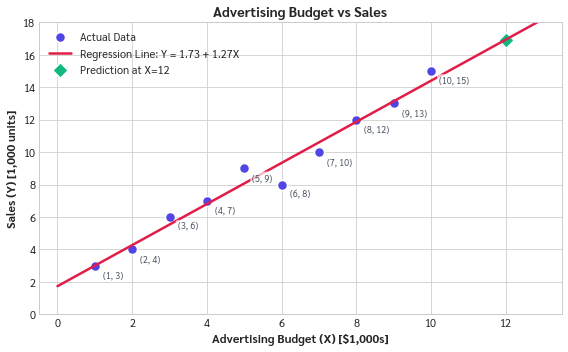

In [8]:
# --- Plot 1: Scatter + Regression Line ---
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.scatter(X, Y, color='#4F46E5', s=100, edgecolors='white', linewidths=1.5, label='Actual Data')
X_line = np.linspace(0, 13, 100)
ax1.plot(X_line, alpha + beta * X_line, color='#E11D48', linewidth=2.5, label=fr'Regression Line: Y = {alpha:.2f} + {beta:.2f}X')
ax1.scatter([12], [alpha + beta * 12], color='#10B981', s=120, marker='D', edgecolors='white', linewidths=1.5, label='Prediction at X=12')

for i in range(n):
    ax1.annotate(f'({X[i]:.0f}, {Y[i]:.0f})', (X[i], Y[i]), textcoords='offset points', xytext=(8, -12), fontproperties=prop_small, color='#4B5563', bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

ax1.set_xlabel('Advertising Budget (X) [$1,000s]', fontproperties=prop_b)
ax1.set_ylabel('Sales (Y) [1,000 units]', fontproperties=prop_b)
ax1.set_title('Advertising Budget vs Sales', fontproperties=prop_title)
legend = ax1.legend(prop=prop_r)
apply_font(ax1)
ax1.set_xlim(-0.5, 13.5)
ax1.set_ylim(0, 18)
plt.tight_layout()
fig1.savefig('plot_1_regression.pdf', dpi=300)
plt.show()

## 3. Task 2: Interpretation

### 3a. Meaning of Slope and Intercept

- **Slope (β ≈ 1.2667):** For each additional \$1,000 in advertising budget, sales are predicted to increase by approximately **1,267 units**. This is an association in the sample, not proof of causation.
- **Intercept (α ≈ 1.7333):** At zero advertising budget (X = 0), predicted sales ≈ **1,733 units**. X = 0 is outside the observed range (1–10), so this is an extrapolated baseline.

### 3b. Prediction at X = 12 (\$12,000 budget)

In [9]:
X_pred = 12.0
Y_pred = alpha + beta * X_pred

print(f"X = {X_pred} (i.e., $12,000 advertising budget)")
print(f"Y_hat = {alpha:.4f} + {beta:.4f} * {X_pred} = {Y_pred:.4f} thousand units")
print(f"      ≈ {Y_pred * 1000:,.0f} units")
print()
print("NOTE: X = 12 is beyond the observed maximum (X_max = 10).")
print("This prediction is extrapolation — treat with caution.")
assert np.isclose(Y_pred, 16.9333333333)

X = 12.0 (i.e., $12,000 advertising budget)
Y_hat = 1.7333 + 1.2667 * 12.0 = 16.9333 thousand units
      ≈ 16,933 units

NOTE: X = 12 is beyond the observed maximum (X_max = 10).
This prediction is extrapolation — treat with caution.


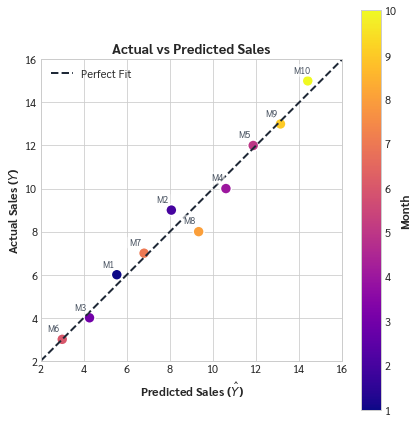

In [10]:
# --- Plot 7: Actual vs Predicted ---
fig7, ax7 = plt.subplots(figsize=(6, 6))
sc = ax7.scatter(Y_hat, Y, c=months, cmap='plasma', s=120, edgecolors='white', linewidths=1.5)
cbar = fig7.colorbar(sc, ax=ax7)
cbar.set_label('Month', fontproperties=prop_b)
cbar.ax.tick_params(labelsize=11)
for t in cbar.ax.get_yticklabels():
    t.set_fontproperties(prop_r)

lims = [min(Y.min(), Y_hat.min()) - 1, max(Y.max(), Y_hat.max()) + 1]
ax7.plot(lims, lims, color='#1F2937', linestyle='--', linewidth=2, label='Perfect Fit')

for i in range(n):
    ax7.annotate(f'M{i+1}', (Y_hat[i], Y[i]), textcoords='offset points', xytext=(-15, 8), fontproperties=prop_small, color='#4B5563', bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6))

ax7.set_xlabel(r'Predicted Sales ($\hat{Y}$)', fontproperties=prop_b)
ax7.set_ylabel('Actual Sales ($Y$)', fontproperties=prop_b)
ax7.set_title('Actual vs Predicted Sales', fontproperties=prop_title)
ax7.legend(prop=prop_r)
apply_font(ax7)
ax7.set_xlim(lims)
ax7.set_ylim(lims)
ax7.set_aspect('equal')
plt.tight_layout()
fig7.savefig('plot_7_actual_vs_pred.pdf', dpi=300)
plt.show()

## 4. Task 3: Model Evaluation

### 4a. R² Calculation

$$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}, \quad SS_{\text{res}} = \sum e_i^2, \quad SS_{\text{tot}} = \sum (Y_i - \bar{Y})^2$$

In [11]:
SS_res = np.sum(residuals ** 2)
SS_tot = np.sum((Y - Y_bar) ** 2)
R2     = 1 - SS_res / SS_tot

print(f"SS_res = {SS_res:.6f}")
print(f"SS_tot = {SS_tot:.4f}")
print(f"R²     = {R2:.6f}  ({R2*100:.2f}%)")
print()
print(f"Residual mean = {residuals.mean():.6f}  (≈ 0 → no bias)")
print(f"Residual std  = {residuals.std(ddof=1):.6f}")

assert np.isclose(SS_res, 3.7333333333)
assert np.isclose(SS_tot, 136.1)
assert np.isclose(R2, 0.9725691893)
print("\n[OK] All assertions passed")

SS_res = 3.733333
SS_tot = 136.1000
R²     = 0.972569  (97.26%)

Residual mean = 0.000000  (≈ 0 → no bias)
Residual std  = 0.644061

[OK] All assertions passed


### 4b. Interpretation

97.26% of the observed variation in sales is explained by the fitted linear relationship with advertising budget.

**Important caveats:**
- High R² does **not** establish that advertising *causes* higher sales.
- R² alone does not guarantee the model will predict well on new data.
- Residual mean ≈ 0 confirms the model is unbiased over the sample.

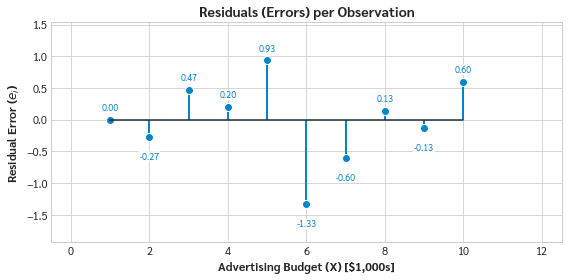

In [12]:
# --- Plot 2: Residuals Lollipop Chart ---
fig2, ax2 = plt.subplots(figsize=(8, 4))
markerline, stemlines, baseline = ax2.stem(X, residuals, linefmt='-', markerfmt='o', basefmt='k-')
plt.setp(markerline, color='#0284C7', markersize=8, markeredgecolor='white', markeredgewidth=1)
plt.setp(stemlines, color='#0284C7', linewidth=2)
plt.setp(baseline, color='#1F2937', linewidth=1.5)

for i in range(n):
    offset = 0.15 if residuals[i] > 0 else -0.35
    ax2.text(X[i], residuals[i] + offset, f'{residuals[i]:.2f}', ha='center', fontproperties=prop_small, color='#0284C7', bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.8))

ax2.set_xlabel('Advertising Budget (X) [$1,000s]', fontproperties=prop_b)
ax2.set_ylabel('Residual Error ($e_i$)', fontproperties=prop_b)
ax2.set_title('Residuals (Errors) per Observation', fontproperties=prop_title)
apply_font(ax2)
ax2.set_xlim(-0.5, 12.5)
ax2.set_ylim(min(residuals) - 0.6, max(residuals) + 0.6)
plt.tight_layout()
fig2.savefig('plot_2_residuals_lollipop.pdf', dpi=300)
plt.show()

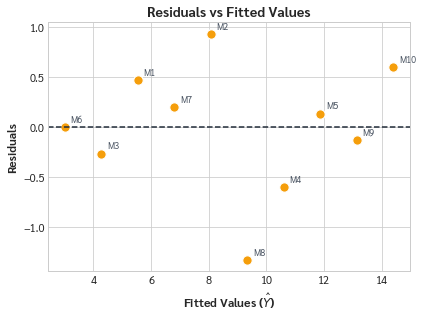

In [13]:
# --- Plot 3: Residuals vs Fitted ---
fig3, ax3 = plt.subplots(figsize=(6, 4.5))
ax3.scatter(Y_hat, residuals, color='#F59E0B', s=90, edgecolors='white', linewidths=1.2)
ax3.axhline(0, color='#1F2937', linestyle='--', linewidth=1.5)
for i in range(n):
    ax3.annotate(f'M{i+1}', (Y_hat[i], residuals[i]), textcoords='offset points', xytext=(6, 5), fontproperties=prop_small, color='#4B5563')
ax3.set_xlabel(r'Fitted Values ($\hat{Y}$)', fontproperties=prop_b)
ax3.set_ylabel('Residuals', fontproperties=prop_b)
ax3.set_title('Residuals vs Fitted Values', fontproperties=prop_title)
apply_font(ax3)
plt.tight_layout()
fig3.savefig('plot_3_res_vs_fitted.pdf', dpi=300)
plt.show()

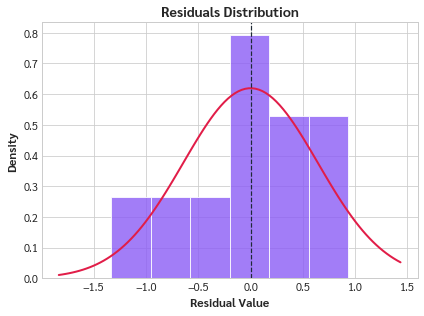

In [14]:
# --- Plot 4: Residual Distribution (Histogram) ---
fig4, ax4 = plt.subplots(figsize=(6, 4.5))
ax4.hist(residuals, bins=6, color='#8B5CF6', edgecolor='white', alpha=0.8, density=True)
x_range = np.linspace(residuals.min() - 0.5, residuals.max() + 0.5, 100)
ax4.plot(x_range, stats.norm.pdf(x_range, 0, residuals.std(ddof=1)), color='#E11D48', linewidth=2)
ax4.axvline(0, color='#1F2937', linestyle='--', linewidth=1.2)
ax4.set_xlabel('Residual Value', fontproperties=prop_b)
ax4.set_ylabel('Density', fontproperties=prop_b)
ax4.set_title('Residuals Distribution', fontproperties=prop_title)
apply_font(ax4)
plt.tight_layout()
fig4.savefig('plot_4_res_dist.pdf', dpi=300)
plt.show()

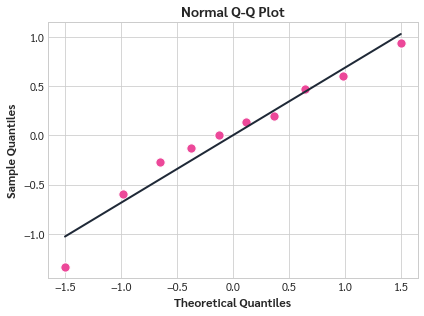

In [15]:
# --- Plot 5: Normal Q-Q Plot ---
fig5, ax5 = plt.subplots(figsize=(6, 4.5))
(osm, osr), (slope_qq, intercept_qq, _) = stats.probplot(residuals, dist='norm')
ax5.scatter(osm, osr, color='#EC4899', s=90, edgecolors='white', linewidths=1.2)
xq = np.array([osm.min(), osm.max()])
ax5.plot(xq, slope_qq * xq + intercept_qq, color='#1F2937', linewidth=2)
ax5.set_xlabel('Theoretical Quantiles', fontproperties=prop_b)
ax5.set_ylabel('Sample Quantiles', fontproperties=prop_b)
ax5.set_title('Normal Q-Q Plot', fontproperties=prop_title)
apply_font(ax5)
plt.tight_layout()
fig5.savefig('plot_5_qq.pdf', dpi=300)
plt.show()

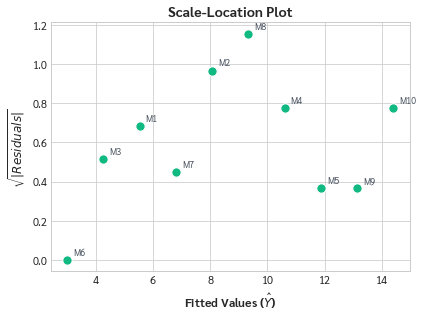

In [16]:
# --- Plot 6: Scale-Location Plot ---
fig6, ax6 = plt.subplots(figsize=(6, 4.5))
sqrt_abs_res = np.sqrt(np.abs(residuals))
ax6.scatter(Y_hat, sqrt_abs_res, color='#10B981', s=90, edgecolors='white', linewidths=1.2)
for i in range(n):
    ax6.annotate(f'M{i+1}', (Y_hat[i], sqrt_abs_res[i]), textcoords='offset points', xytext=(6, 5), fontproperties=prop_small, color='#4B5563')
ax6.set_xlabel(r'Fitted Values ($\hat{Y}$)', fontproperties=prop_b)
ax6.set_ylabel(r'$\sqrt{|Residuals|}$', fontproperties=prop_b)
ax6.set_title('Scale-Location Plot', fontproperties=prop_title)
apply_font(ax6)
plt.tight_layout()
fig6.savefig('plot_6_scale_loc.pdf', dpi=300)
plt.show()

## 6. Summary of Results

| Task | Answer |
|------|--------|
| **1a** | Normal Equations: $10\alpha + 55\beta = 87$, $55\alpha + 385\beta = 583$ |
| **1b** | Intercept $\alpha \approx 1.7333$, Slope $\beta \approx 1.2667$ |
| **1c** | Fitted line: $\hat{Y} = 1.7333 + 1.2667X$ |
| **2a** | Slope: +\$1,000 ads → +1,267 units sold (association, not causation) |
| **2b** | At \$12,000 budget: $\hat{Y} \approx 16.93$ thousand units ≈ 16,933 units (extrapolation) |
| **3a** | $R^2 \approx 0.9726$ (97.26%) |
| **3b** | 97.26% of sales variation explained by advertising budget; residual mean = 0 (no bias) |